# Notebook Notes
- random seed = 53 for randomized samples of full corpus
- random seed = 44 for randomized samples of individual topics

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import bigrams
import datetime

# Aggregate at tweet level

In [517]:
df = pd.read_csv('df.csv', dtype={'tweetId': str})

# Aggregate at the tweetId level (and english-only)

df['tweetId'] = df['tweetId'].astype(str)
# filter for english notes and notes marked 'MISINFORMED_OR_POTENTIALLY_MISLEADING'
df_english = df[(df['is_english'] == True) & (df['classification'] == 'MISINFORMED_OR_POTENTIALLY_MISLEADING')]
tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'any'), 
    is_trump=('is_trump', 'any'),
    is_israel=('is_israel', 'any'),
    is_covid=('is_covid', 'any'),
    is_earthquakesmall=('is_earthquakesmall', 'any'),
    got_shown=('got_shown', 'max'),
    is_cancer=('is_cancer', 'any'),
    hours_to_show=('hours_to_show', 'min'),
    noteId=('noteId', lambda x: ','.join(map(str, x.unique())))
).reset_index()

/var/folders/z0/qzq8g2qx44lcdrv4wy390xdc0000gs/T/ipykernel_21901/1596743452.py:1: DtypeWarning: Columns (1,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('df.csv', dtype={'tweetId': str})


# Initial exploratory analysis and checking for biases

In [166]:
# Number of total English-language notes submitted to the system:
len(df_english)

668683

In [168]:
# Number of tweets receiving at least one note:
df_english['tweetId'].nunique()

521636

In [170]:
# Find percentage for each keyword group
len(tweet_level)

521636

In [172]:
tweet_level.is_political.sum()

262846

In [176]:
tweet_level.is_israel.sum()

33318

In [178]:
# Number of tweets that achieve either CRH (Currently Rated Helpful) or CRNH (Currently Rated Not Helpful):
tweet_level = df_english.groupby('tweetId').agg(
    is_followedup=('is_followedup', 'any'))
tweet_level.is_followedup.sum()

106151

In [180]:
# do english vs non-english notes get followed up or approved at different rates? what are they?
# using firstNonNMRStatus column (containing either CRH or CRNH) as proxy for getting followed up on. 
# Not perfect proxy - notes will occassionally get pushed back to NMR if contradictory ratings are submitted)
df.groupby('is_english').is_followedup.sum()

is_english
False    122084
True     147588
Name: is_followedup, dtype: int64

In [182]:
df.groupby('is_english').is_followedup.mean()

is_english
False    0.185970
True     0.162135
Name: is_followedup, dtype: float64

In [184]:
# Looking to see if a small group of raters submit the majority of the Notes - answer: I don't think so!

series = df.groupby('noteAuthorParticipantId_x').size().sort_values(ascending=False)

author_counts_df = series.reset_index()
author_counts_df.columns = ['noteAuthorParticipantId_x', 'count']
author_counts_df.to_csv('author_counts_df.csv', index=False)

top_1000_sum = author_counts_df.head(1000)['count'].sum()

total_sum = author_counts_df['count'].sum()

percentage = (top_1000_sum / total_sum) * 100

print(f"Top 1000 raters constitute {percentage:.2f}% of the total Notes submitted")

Top 1000 raters constitute 21.46% of the total Notes submitted


In [186]:
author_counts_df['count'].sum()

1407576

# Got Shown and Recall

In [196]:
# Calculate percentage of notes that got shown - corroborate previous studies from literature
df_english.got_shown.mean()

0.1448892823654856

In [194]:
# Overall got_shown rate (tweet level):
tweet_level.got_shown.mean()

0.14899470128595418

In [51]:
# The following 3 cells calculate the number of tweets with and without warnings for each topic area, which we used to calculate recall and precision.
# See Appendix A (Random Manual Labeling; Recall Rate) in paper for details about calculating recall.

keywords = ['political', 'covid', 'trump', 'cancer', 'earthquakesmall', 'israel']
results = []

for keyword in keywords:
    counts = (
        tweet_level
        .groupby([f'is_{keyword}', 'got_shown'])
        .size()
        .reset_index(name='count')
        .rename(columns={f'is_{keyword}': 'is_topic'})
    )
    counts['keyword'] = keyword
    results.append(counts)

got_shown_df = pd.concat(results, ignore_index=True)
got_shown_df.to_csv('got_shown_df.csv', index=False)

In [59]:
# for NOT political

tweet_level[tweet_level['is_political'] == False].groupby('got_shown').size()

got_shown
0    218615
1     40175
dtype: int64

In [204]:
# Overall got_shown - use for recall:
tweet_level.groupby('got_shown').size()

got_shown
0    443915
1     77721
dtype: int64

# Hours to Show

In [236]:
# calculate median hours to show for each category
keywords = ['political', 'covid', 'trump', 'cancer', 'earthquakesmall', 'israel']

for keyword in keywords:
    new_keyword = f'is_{keyword}'
    median_result = tweet_level.groupby(new_keyword)['hours_to_show'].median()
    print(f"{new_keyword}: {median_result}")

is_political: is_political
False    7.348474
True     6.247829
Name: hours_to_show, dtype: float64
is_covid: is_covid
False    6.796931
True     6.681038
Name: hours_to_show, dtype: float64
is_trump: is_trump
False    6.824779
True     5.988331
Name: hours_to_show, dtype: float64
is_cancer: is_cancer
False    6.799462
True     6.384059
Name: hours_to_show, dtype: float64
is_earthquakesmall: is_earthquakesmall
False    6.788928
True     7.314328
Name: hours_to_show, dtype: float64
is_israel: is_israel
False    6.892027
True     5.389168
Name: hours_to_show, dtype: float64


In [226]:
# calculate overall median hours to show:
tweet_level.hours_to_show.median()

6.793271944444444

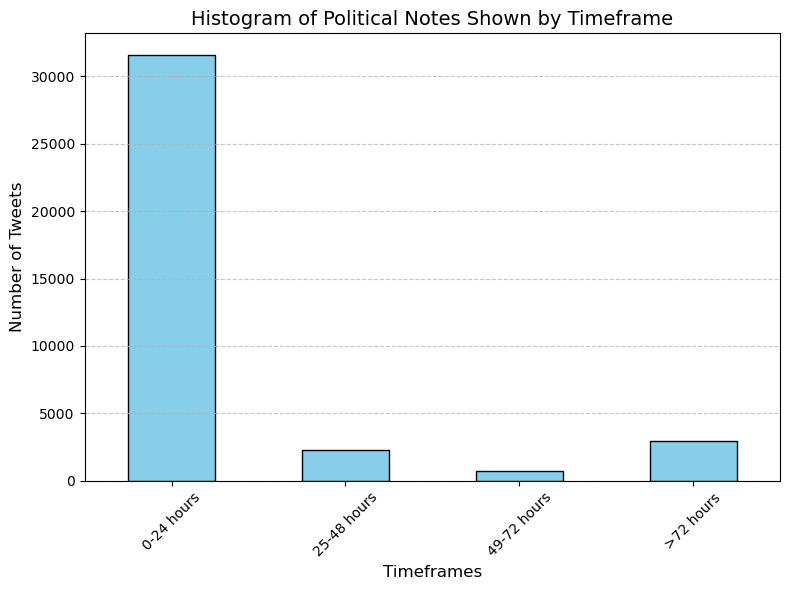

In [238]:
# Histogram of timeframes to get approved/posted:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for political notes that got shown
df_english = df[df['is_english'] == True]

filtered = tweet_level[(tweet_level['is_political'] == True) & (tweet_level['got_shown'] == 1)].copy()

# Create bins for timeframes
bins = [0, 24, 48, 72, float('inf')]  # Define bin edges
labels = ['0-24 hours', '25-48 hours', '49-72 hours', '>72 hours']  # Bin labels
filtered.loc[:, 'timeframe'] = pd.cut(filtered['hours_to_show'], bins=bins, labels=labels)

# Count notes in each timeframe
timeframe_counts = filtered['timeframe'].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 6))
timeframe_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Histogram of Political Notes Shown by Timeframe', fontsize=14)
plt.xlabel('Timeframes', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

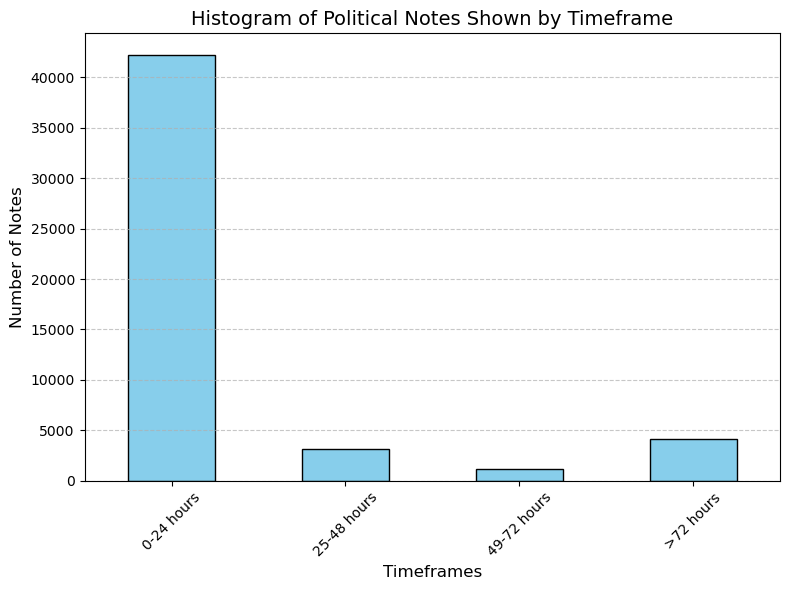

In [240]:
# Histogram of timeframes to get approved/posted:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for political notes that got shown
df_english = df[df['is_english'] == True]

filtered = df_english[(df_english['is_political'] == True) & (df_english['got_shown'] == 1)].copy()

# Create bins for timeframes
bins = [0, 24, 48, 72, float('inf')]  # Define bin edges
labels = ['0-24 hours', '25-48 hours', '49-72 hours', '>72 hours']  # Bin labels
filtered.loc[:, 'timeframe'] = pd.cut(filtered['hours_to_show'], bins=bins, labels=labels)

# Count notes in each timeframe
timeframe_counts = filtered['timeframe'].value_counts().sort_index()

# Plot histogram
plt.figure(figsize=(8, 6))
timeframe_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Histogram of Political Notes Shown by Timeframe', fontsize=14)
plt.xlabel('Timeframes', fontsize=12)
plt.ylabel('Number of Notes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Random samples for manual labeling

In [52]:
# Random sample of 10 tweets that got warnings and 10 that didn't (sample of OVERALL tweets)
tweet_level = df_english.groupby('tweetId').agg( 
    got_shown=('got_shown', 'max') 
)
tweet_warnings_rand = tweet_level[tweet_level['got_shown'] == 1].sample(frac=1, random_state=53).reset_index()
tweet_warnings_rand = tweet_warnings_rand.head(100)
tweet_warnings_rand.to_csv('tweet_warnings_rand.csv', index=False)

tweet_nowarnings_rand = tweet_level[tweet_level['got_shown'] == 0].sample(frac=1, random_state=53).reset_index()
tweet_nowarnings_rand = tweet_nowarnings_rand.head(100)
tweet_nowarnings_rand.to_csv('tweet_nowarnings_rand.csv', index=False)

In [509]:
#Function: tweet level, keyword-specific, random sample of 100 that got warnings and 100 that didn't

def keyword_rand(keyword):
    filtered = tweet_level[
        (tweet_level[f'is_{keyword}'] == True) &
        (tweet_level['got_shown'] == 1)
    ].sample(frac=1, random_state=44).reset_index()

    keyword_warning_rand = filtered.head(100)
    keyword_warning_rand.to_csv(f'{keyword}_warning_rand.csv', index=False)

    filtered = tweet_level[
        (tweet_level[f'is_{keyword}'] == True) &
        (tweet_level['got_shown'] == 0)
    ].sample(frac=1, random_state=44).reset_index()

    keyword_nowarning_rand = filtered.head(100)
    keyword_nowarning_rand.to_csv(f'{keyword}_nowarning_rand.csv', index=False)

    return keyword_warning_rand, keyword_nowarning_rand

def keyword_rand_not_containing(keyword):
    filtered = tweet_level[
        (tweet_level[f'is_{keyword}'] == False) &
        (tweet_level['got_shown'] == 1)
    ].sample(frac=1, random_state=44).reset_index()

    keyword_warning_rand = filtered.head(100)
    keyword_warning_rand.to_csv(f'NOT {keyword}_warning_rand.csv', index=False)

    filtered = tweet_level[
        (tweet_level[f'is_{keyword}'] == False) &
        (tweet_level['got_shown'] == 0)
    ].sample(frac=1, random_state=44).reset_index()

    keyword_nowarning_rand = filtered.head(100)
    keyword_nowarning_rand.to_csv(f'NOT {keyword}_nowarning_rand.csv', index=False)

    return keyword_warning_rand, keyword_nowarning_rand

In [88]:
# call function for each keyword and save file to working directory of 100 random tweets from each topic
keywords = ['political', 'covid', 'trump', 'cancer', 'earthquakesmall', 'israel']

for keyword in keywords:
    keyword_rand(keyword)

keyword_rand_not_containing('political')

In [511]:
keyword_rand('cancer')

(     index              tweetId  is_political  is_trump  is_israel  is_covid  \
 0   310398  1787106057631805860         False     False      False     False   
 1   110676  1709162632987496814          True     False      False     False   
 2   473584  1837514632203796847         False     False      False     False   
 3   196098  1744806869217021967          True     False      False     False   
 4   267661  1771975968451596523         False     False      False     False   
 ..     ...                  ...           ...       ...        ...       ...   
 95   58367  1661894568445640706         False     False      False     False   
 96   72546  1678202096707940352         False     False      False      True   
 97   37314  1628906505344020480          True     False      False     False   
 98  185126  1741187455498207281         False     False      False     False   
 99  224481  1755192819713536383          True     False      False     False   
 
     is_earthquakesmall  g

# Notes on reproducibility of random samples

In [ ]:
# When we originally created random samples, we had not yet removed notes not marked "MISINFORMED_OR_POTENTIALLY_MISLEADING." 
# For future researchers running this notebook, the random samples will not match those found in our labeled samples. 
# In order to reproduce our original random samples, you will need to run the following cells and then rerun the random sample cells above.

In [ ]:
# This cell will create our original "tweet_level" which was used to create the original random samples. 
# The next 2 cells walk you through our process to remove any notes not marked as 'MISINFORMED_OR_POTENTIALLY_MISLEADING'

# You will need to remove #s for the next 3 cells before running.

#df = pd.read_csv('df.csv', dtype={'tweetId': str})

#df['tweetId'] = df['tweetId'].astype(str)
#df_english = df[(df['is_english'] == True)]
#tweet_level = df_english.groupby('tweetId').agg(
    is_political=('is_political', 'any'), 
    is_trump=('is_trump', 'any'),
    is_israel=('is_israel', 'any'),
    is_covid=('is_covid', 'any'),
    is_earthquakesmall=('is_earthquakesmall', 'any'),
    got_shown=('got_shown', 'max'),
    is_cancer=('is_cancer', 'any'),
    hours_to_show=('hours_to_show', 'min'),
    noteId=('noteId', lambda x: ','.join(map(str, x.unique())))
).reset_index()

In [ ]:
# filter for tweetIds that are NOT marked as 'MISINFORMED_OR_POTENTIALLY_MISLEADING', 
# to remove from manually labeled datasets (used to calculate recall)

#df = pd.read_csv('df.csv', dtype={'tweetId': str})

#misleading_tweet_ids = df[df['classification'] == 'MISINFORMED_OR_POTENTIALLY_MISLEADING']['tweetId'].unique()

#df_english2 = df[(df['is_english'] == True) & (~df['tweetId'].isin(misleading_tweet_ids))]

#tweet_level2 = df_english2.groupby('tweetId').agg(
    is_political=('is_political', 'any'), 
    is_trump=('is_trump', 'any'),
    is_israel=('is_israel', 'any'),
    is_covid=('is_covid', 'any'),
    is_earthquakesmall=('is_earthquakesmall', 'any'),
    got_shown=('got_shown', 'max'),
    is_cancer=('is_cancer', 'any'),
    hours_to_show=('hours_to_show', 'min')
).reset_index()

#tweet_level2.to_csv('tweet_level2.csv', index=False)

In [ ]:
# removing any of the tweets that did not have notes marked as 'MISINFORMED_OR_POTENTIALLY_MISLEADING' 
# When we originally created the nowarning_rand files, we had not yet filtered out tweets whose notes did not include 'potentially misleading'
# Did this for all topic categories and recalculated recall as needed. See Appendix A "Not Misleading" section for details.
#tweet_nowarnings_rand = pd.read_csv(
    'Manually Labeled Random Samples/tweet_nowarnings_rand.csv', 
    dtype={'tweetId': str}
)
#tweet_level2 = pd.read_csv(
    'tweet_level2.csv', 
    dtype={'tweetId': str}
)

#tweet_nowarnings_rand['tweetId'] = tweet_nowarnings_rand['tweetId'].str.strip()
#tweet_level2['tweetId'] = tweet_level2['tweetId'].str.strip()

#tweet_nowarnings_filtered = tweet_nowarnings_rand[
    ~tweet_nowarnings_rand['tweetId'].isin(tweet_level2['tweetId'])
]

#tweet_nowarnings_filtered.to_csv('tweet_nowarnings_filtered.csv', index=False)

# Note Submissions Count

In [258]:
df_english = df_english.copy()

In [244]:
# Create function that sums the # of notes for each is____ keyword list and puts into a dataframe:
submission_summary = []

def count_submissions(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['noteId'].nunique()
        keyword_submission_count = result.loc[True] if True in result.index else 0
        submission_summary.append({'keyword': keyword, 'submission_count': keyword_submission_count})
    else:
        print(f"Column '{col}' not found.")

submission_summary_not = []

def count_submissions_not_containing(keyword):
    col = f'is_{keyword}'
    if col in df_english.columns:
        result = df_english.groupby(col)['noteId'].nunique()
        # Get count where is_{keyword} == False instead of True
        keyword_exclusion_count = result.loc[False] if False in result.index else 0
        submission_summary_not.append({'keyword': f'NOT {keyword}', 'submission_count': keyword_exclusion_count})
    else:
        print(f"Column '{col}' not found.")

In [246]:
# call function for each topic:
keywords = ['political', 'covid', 'trump', 'cancer', 'earthquakesmall', 'israel']
for keyword in keywords:
    count_submissions(keyword)

submission_count = pd.DataFrame(submission_summary)
submission_count.to_csv('submission_count.csv', index=False)

In [248]:
count_submissions_not_containing('political')

submission_count_not = pd.DataFrame(submission_summary_not)
submission_count_not.to_csv('submission_count_not.csv', index=False)

In [260]:
# count total number of unique NoteIds (# of unique submissions)
df_english['noteId'].nunique()

668683

# Tweets Count

In [262]:
tweet_summary = []

def count_tweets(keyword):
    col = f'is_{keyword}'
    if col in tweet_level.columns:
        result = tweet_level.groupby(col)['noteId'].nunique()
        keyword_tweet_count = result.loc[True] if True in result.index else 0
        tweet_summary.append({'keyword': keyword, 'tweet_count': keyword_tweet_count})
    else:
        print(f"Column '{col}' not found.")

In [268]:
# call function for each keyword:
keywords = ['political', 'israel', 'trump', 'covid', 'earthquakesmall', 'cancer']
for keyword in keywords:
    count_tweets(keyword)

tweet_count = pd.DataFrame(tweet_summary)
tweet_count.to_csv('tweet_count.csv', index=False)

In [136]:
# count total number of unique tweets (# of unique submissions)
df_english['tweetId'].nunique()

521636

In [288]:
# Create function that plots # of submissions for keyword or keyword list:

def plot_keywords_mixed(keywords_dict, search_col='summary'):
    collection_date = pd.Timestamp('2024-11-14')
    last_complete_week = collection_date - datetime.timedelta(days=collection_date.dayofweek + 1)

    # Ensure you're working on a fresh copy to avoid SettingWithCopyWarning
    df = df_english.copy()
    df['created_at'] = pd.to_datetime(df['createdAtMillis_x'], unit='ms')
    df_complete = df[df['created_at'] <= last_complete_week]

    plt.figure(figsize=(20, 10))

    weekly_all = df_complete.set_index('created_at').resample('W').size()
    plt.plot(weekly_all.index, weekly_all.values, lw=2.5, linestyle='--', marker='o',
             label='All Notes', alpha=0.6)

    for keyword, mode in keywords_dict.items():
        if mode == 'column':
            mask = df.get(f'is_{keyword}', pd.Series(False, index=df.index))
        elif mode == 'search':
            mask = df[search_col].str.contains(fr'\b{keyword}\b', case=False, na=False, regex=True)
        else:
            raise ValueError(f"Unknown mode '{mode}' for keyword '{keyword}' (use 'column' or 'search')")

        keyword_notes = df[mask & (df['created_at'] <= last_complete_week)].copy()
        weekly_keyword = keyword_notes.set_index('created_at').resample('W').size()

        plt.plot(weekly_keyword.index, weekly_keyword.values, lw=2.5, marker='o',
                 label=f'{keyword} ({mode})')

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axvline(x=last_complete_week, color='r', linestyle='--', alpha=0.7)
    plt.text(last_complete_week - datetime.timedelta(days=15), plt.ylim()[1]*0.9, 
             'Data collected on Nov 14, 2024', 
             rotation=90, verticalalignment='top', color='red')

    plt.title('Community Notes Submissions', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Submissions', fontsize=12)
    plt.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

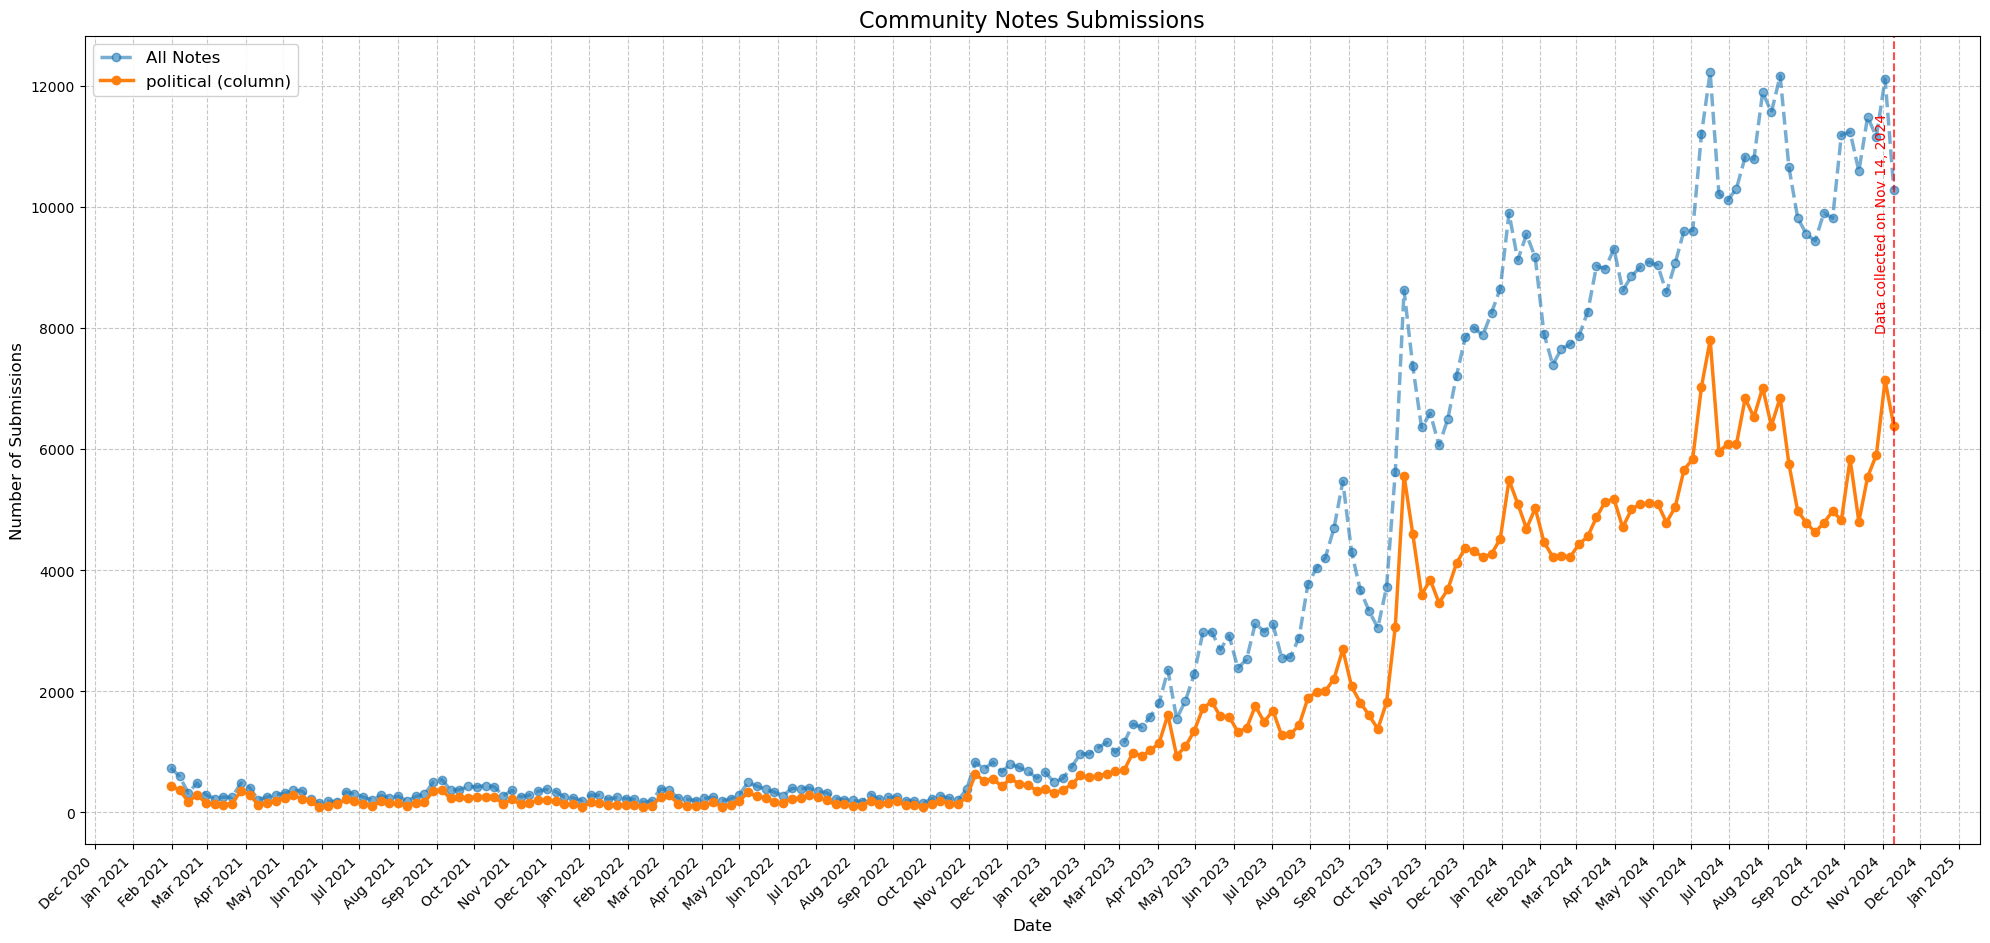

In [290]:
plot_keywords_mixed({
    'political': 'column',
    
})

# Ratings Count

In [535]:
# preprocessing ratings to use in the next cell (takes 2-3 min)

all_ratings2 = pd.read_csv("all_ratings.csv", usecols=['noteId'])
ratings_count = all_ratings2['noteId'].value_counts().reset_index()
ratings_count.columns = ['noteId', 'rating_count']

In [541]:
df_english = df_english.merge(ratings_count, on='noteId', how='left')
len(df_english)

668683

In [9]:
# How many ratings per note in descending order (for notes with less than 5 ratings)
df_filtered = df_english[(df_english['rating_count'] < 5) | (df_english['rating_count'].isna())]
df_filtered_sorted = df_filtered.sort_values(by='rating_count', ascending=True)
df_filtered_sorted.to_csv('df_english_sorted.csv', index=False)
len(df_filtered_sorted)

171372

In [17]:
# total % of notes that received <5 ratings overall:
(len(df_filtered)/len(df_english))

0.2562828724522681

In [156]:
# Calculate % of notes that receive <5 ratings for a given subtopic:
under5 = []

def percent_under5_ratings(df, keyword):
    column_name = f"is_{keyword}"
    
    if column_name not in df.columns:
        return None
    
    under5_mask = (df[column_name] == True) & ((df['rating_count'] < 5) | (df['rating_count'].isna()))
    keyword_mask = df[column_name] == True
    
    if keyword_mask.sum() == 0:  
        result = {'keyword': keyword, 'percent_under5': 0}
    else:
        percentage = under5_mask.sum() / keyword_mask.sum()
        result = {'keyword': keyword, 'percent_under5': percentage}
    
    under5.append(result)
    return result

In [164]:
keywords = ['political', 'israel', 'trump', 'covid', 'earthquakesmall', 'cancer']

for keyword in keywords:
    percent_under5_ratings(df_english, keyword)

under5 = pd.DataFrame(under5)
under5.to_csv('under5.csv', index=False)

In [312]:
# calculate median # of ratings per note for each topic:

def count_ratings_all(keywords):
    results = []
    for keyword in keywords:
        col = f'is_{keyword}'
        if col in df_english.columns:
            result = df_english.groupby(col)['rating_count'].median()
            rating = result.loc[True] if True in result.index else 0
            results.append({'keyword': keyword, 'rating_count': rating})
        else:
            print(f"Column '{col}' not found.")
    return pd.DataFrame(results)

keywords = ['political', 'israel', 'trump', 'covid', 'earthquakesmall', 'cancer']
rating_summary = count_ratings_all(keywords)
rating_summary.to_csv('rating_summary.csv', index=False)

In [310]:
# calculate median # of ratings per note for is_political and NOT is_political
df_english.groupby('is_political')['rating_count'].median()

is_political
False    18.0
True     40.0
Name: rating_count, dtype: float64

In [543]:
# calculate median # of ratings overall
df_english['rating_count'].median()

29.0

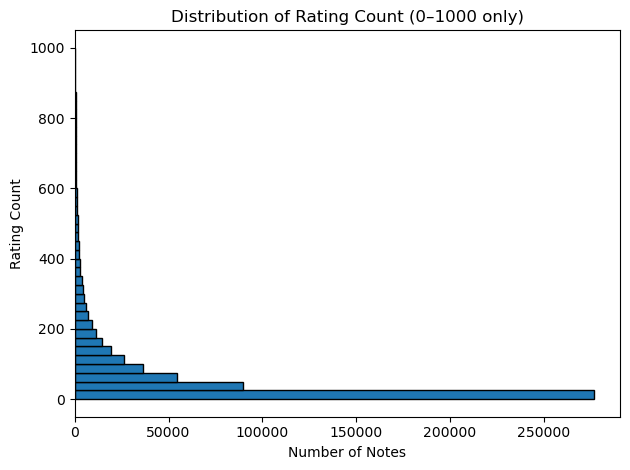

In [573]:
# plotting the distribution of ratings per note (for all notes in the corpus)

subset = df_english[df_english['rating_count'] <= 5000]
subset['rating_count'].plot(
    kind='hist',
    bins=range(0, 1001, 25),
    edgecolor='black',
    orientation='horizontal'  # <-- this flips the axes
)

plt.ylabel('Rating Count')      # flipped
plt.xlabel('Number of Notes')         # flipped
plt.title('Distribution of Rating Count (0–1000 only)')
plt.tight_layout()
plt.show()



# Statistical Analysis

In [ ]:
# In the end, we did not use correlations in our report, however we ran the following calculations during our exploratory data analysis.
# To run the following cells, you will need to create a spreadsheet called 'Findings - CorrelationData.csv' that contains:
# Topic, Recall, Engagement, % <5 ratings, and Percent >Helpful. * see Appendix B in paper

In [579]:
# calculating correlation coefficient for recall and ratings <5:
df_correlation = pd.read_csv('Findings - CorrelationData.csv')
df_correlation['Recall'] = df_correlation['Recall'].str.replace('%', '').astype(float)
df_correlation['% <5 ratings'] = df_correlation['% <5 ratings'].str.replace('%', '').astype(float)
correlation = df_correlation['Recall'].corr(df_correlation['% <5 ratings'])
print(correlation)

-0.4001633170687499


In [531]:
# calculate correlation between recall and rating medians (removing Israel - the outlier)
df_correlation = pd.read_csv('Findings - CorrelationData.csv')
df_correlation['Recall'] = df_correlation['Recall'].str.replace('%', '').astype(float)
df_correlation['Engagement'] = df_correlation['Engagement']
correlation = df_correlation['Recall'].corr(df_correlation['Engagement'])
print(correlation)

0.17956521646224244


In [577]:
# calculate correlation between Percent >Helpful and Recall:
df_correlation = pd.read_csv('Findings - CorrelationData.csv')
df_correlation['Recall'] = df_correlation['Recall'].str.replace('%', '').astype(float)
df_correlation['Percent >Helpful'] = df_correlation['Percent >Helpful'].str.replace('%', '').astype(float)
correlation = df_correlation['Recall'].corr(df_correlation['Engagement'])
print(correlation)

0.17956521646224244


In [575]:
# calculate correlation between Percent <5 ratings and engagement median:
df_correlation = pd.read_csv('Findings - CorrelationData.csv')
df_correlation['% <5 ratings'] = df_correlation['% <5 ratings'].str.replace('%', '').astype(float)
correlation = df_correlation['Engagement'].corr(df_correlation['% <5 ratings'])
print(correlation)

-0.7590070961756961


# Views

In [587]:
# calculate median # of views for misleading tweets without warnings (for each topic):

def median_views_by_truth(file_path, results_list=None):
    if results_list is None:
        results_list = []

    label = os.path.basename(file_path).replace('.csv', '')

    try:
        sample_df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")
        return results_list

    sample_df = sample_df.copy()
    sample_df['views'] = sample_df['views'].astype(str).str.replace(',', '').str.strip()
    sample_df['views'] = pd.to_numeric(sample_df['views'], errors='coerce')

    if 'true?' not in sample_df.columns:
        print(f"Missing 'true?' column in {file_path}")
        return results_list

    sample_df['truth_clean'] = sample_df['true?'].astype(str).str.strip().str.upper()

    truthy_values = ['TRUE', 'OPINION']
    falsey_value = 'FALSE'

    true_median = sample_df[sample_df['truth_clean'].isin(truthy_values)]['views'].median()
    false_median = sample_df[sample_df['truth_clean'] == falsey_value]['views'].median()

    results_list.append({
        'label': label,
        'TRUE_OR_OPINION': true_median,
        'FALSE': false_median
    })

    print(f"Processed {label}")

    return results_list

In [ ]:
samples = [
    'tweet_nowarnings_rand.csv',
    'political_nowarning_rand.csv',
    'NOT political_nowarning_rand.csv',
    'trump_nowarning_rand.csv',
    'covid_nowarning_rand.csv',
    'israel_nowarning_rand.csv',
    'cancer_nowarning_rand.csv',
    'earthquakesmall_nowarning_rand.csv'
]

results = []
for sample in samples:
    results = median_views_by_truth(sample, results)

results_df = pd.DataFrame(results)
results_df.to_csv('results_df.csv', index=False)

In [338]:
# calculate combined (nowarning and warning) median views for each topic category:

def combined_median_views(topic, results):
    base_path = 'Manually Labeled Random Samples'
    file_nowarning = os.path.join(base_path, f'{topic}_nowarning_rand.csv')
    file_warning = os.path.join(base_path, f'{topic}_warning_rand.csv')

    try:
        df_nowarning = pd.read_csv(file_nowarning)
        df_warning = pd.read_csv(file_warning)
    except FileNotFoundError:
        print(f"File not found for topic: {topic}")
        return results

    for df in [df_nowarning, df_warning]:
        df['views'] = df['views'].astype(str).str.replace(',', '', regex=False).str.strip()
        df['views'] = pd.to_numeric(df['views'], errors='coerce')

    combined_views = pd.concat([df_nowarning['views'], df_warning['views']])
    median = combined_views.median()

    results.append({'topic': topic, 'median_views': median})
    return results

In [340]:
keywords = ['political', 'covid', 'trump', 'cancer', 'earthquakesmall', 'israel']
results = []

for keyword in keywords:
    results = combined_median_views(keyword, results)

combined_views = pd.DataFrame(results)
combined_views.to_csv('combined_views.csv', index=False)

# Gauge impact of ideological consensus -  Sum Helpful vs notHelpful ratings

In [5]:
# read in all_ratings and keep only necessary columns (takes 5 minutes)

all_ratings = pd.read_csv("all_ratings.csv")

columns_to_keep = [
    "noteId",
    "ratedOnTweetId",
    "helpfulOther",
    "helpfulClear",
    "helpfulGoodSources",
    "helpfulAddressesClaim",
    "helpfulImportantContext",
    "helpfulUnbiasedLanguage",
    "notHelpfulOther",
    "notHelpfulIncorrect",
    "notHelpfulSourcesMissingOrUnreliable",
    "notHelpfulMissingKeyPoints",
    "notHelpfulHardToUnderstand",
    "notHelpfulArgumentativeOrBiased",
    "notHelpfulSpamHarassmentOrAbuse",
    "notHelpfulIrrelevantSources",
    "notHelpfulOpinionSpeculation",
    "notHelpfulNoteNotNeeded"
]

ratings_filtered = all_ratings[columns_to_keep]

In [7]:
# Find sum for Helpful and notHelpful columns for each tweetId
ratings_aggregated = ratings_filtered.groupby("ratedOnTweetId", as_index=False).sum()

helpful_cols = [col for col in ratings_aggregated.columns if col.startswith("helpful")]
not_helpful_cols = [col for col in ratings_aggregated.columns if col.startswith("notHelpful")]

ratings_summary = ratings_aggregated[["ratedOnTweetId"]].copy()
ratings_summary["helpful_total"] = ratings_aggregated[helpful_cols].sum(axis=1)
ratings_summary["notHelpful_total"] = ratings_aggregated[not_helpful_cols].sum(axis=1)

In [583]:
# Function to count percent of time notes for unflagged tweets received more Helpful ratings than notHelpful (full datasets)

def more_helpful_ratings_full(keyword, ratings_summary):
    df = tweet_level[(tweet_level[f'is_{keyword}'] == True) & (tweet_level["got_shown"] == 0)].copy()
    total = len(df)

    if total == 0:
        return {"keyword": keyword, "more_helpful_ratio": None}

    df["tweetId"] = df["tweetId"].astype(str)
    ratings_summary["ratedOnTweetId"] = ratings_summary["ratedOnTweetId"].astype(str)

    merged_df = df.merge(
        ratings_summary, 
        left_on="tweetId", 
        right_on="ratedOnTweetId", 
        how="left"
    ).drop(columns=["ratedOnTweetId"])

    count = (merged_df["helpful_total"] > merged_df["notHelpful_total"]).sum() / total
    return {"keyword": keyword, "more_helpful_ratio": count}

In [585]:
keywords = ['political', 'covid', 'trump', 'cancer', 'earthquakesmall', 'israel']

results = []

for keyword in keywords:
    result = more_helpful_ratings_full(keyword, ratings_summary)
    results.append(result)

helpful_results_df = pd.DataFrame(results)
helpful_results_df.to_csv('helpful_results_df.csv', index=False)

In [23]:
# count percent of time notes for unflagged tweets received more Helpful ratings than notHelpful (NOT political)

def more_helpful_ratings_full(keyword, ratings_summary):
    df = tweet_level[(tweet_level[f'is_{keyword}']==False) & (tweet_level["got_shown"] == 0)].copy()
    total = len(df)

    df["tweetId"] = df["tweetId"].astype(str)
    ratings_summary["ratedOnTweetId"] = ratings_summary["ratedOnTweetId"].astype(str)
    
    merged_df = df.merge(
        ratings_summary, 
        left_on="tweetId", 
        right_on="ratedOnTweetId", 
        how="left"
    ).drop(columns=["ratedOnTweetId"])
    
    count = (merged_df["helpful_total"] > merged_df["notHelpful_total"]).sum() / total
    print(count)

more_helpful_ratings_full('political', ratings_summary)

0.5377673078242573


In [13]:
# calculate overall percent Helpful>notHelpful

df2 = tweet_level[tweet_level['got_shown'] == 0].copy()
total = len(df2)

df2["tweetId"] = df2["tweetId"].astype(str)
ratings_summary["ratedOnTweetId"] = ratings_summary["ratedOnTweetId"].astype(str)
    
merged_df = df2.merge(
ratings_summary, 
left_on="tweetId", 
right_on="ratedOnTweetId", 
how="left"
).drop(columns=["ratedOnTweetId"])
    
count = (merged_df["helpful_total"] > merged_df["notHelpful_total"]).sum() / total

In [15]:
print(count)

0.5298176452699278


# Adding columnns "rating_count", "helpful_total", and "notHelpful_total" to random sample files

In [99]:
# This section of cells merges rating_summary (containing 'helpful_total' and 'notHelpful_total') with df_english (containing 'rating_count')
# Adds, as new columns, Helpful > notHelpful and ratings < 5 for each tweetId in manually labeled random sample files.
# results in files: "nowarning_count_{keyword}.csv" *changed to "nowarning_count_{keyword}.xlsx" to add colors for clarity in files in github repo.
# These new calculations are used to create the table just before Criterion 1 in paper.

ratings_summary["ratedOnTweetId"] = ratings_summary["ratedOnTweetId"].astype(str) # rating_summary comes from Rating cells above.

merged_df = df.merge(
        ratings_summary, 
        left_on="tweetId", 
        right_on="ratedOnTweetId", 
        how="left"
    ).drop(columns=["ratedOnTweetId"])

In [61]:
merged_df2 = pd.merge(
    merged_df,
    df_english[['noteId', 'rating_count']],  
    on='noteId',
    how='left'
)
merged_df2.to_csv('merged.df2.csv', index=False)

In [56]:
tweet_level2 = merged_df2.groupby('tweetId').agg(
    is_political=('is_political', 'any'), 
    is_trump=('is_trump', 'any'),
    is_israel=('is_israel', 'any'),
    is_covid=('is_covid', 'any'),
    is_earthquakesmall=('is_earthquakesmall', 'any'),
    got_shown=('got_shown', 'max'),
    is_cancer=('is_cancer', 'any'),
    hours_to_show=('hours_to_show', 'min'),
    rating_count=('rating_count', 'sum'),
    helpful_total=('helpful_total', 'sum'),
    notHelpful_total=('notHelpful_total', 'sum'),
    noteId=('noteId', lambda x: ','.join(map(str, x.unique())))
).reset_index()

In [381]:
# add columns (rating_count, helpful_total, and notHelpful_total) to nowarning_rand.csv files

keywords = ['political', 'covid', 'trump', 'cancer', 'earthquakesmall', 'israel']

for keyword in keywords:
    df = pd.read_csv(f'{keyword}_nowarning_rand copy.csv', dtype={'tweetId': str})
    ratings_count_merged = pd.merge(
        df,
        tweet_level2[['tweetId','rating_count', 'helpful_total', 'notHelpful_total']],
        on='tweetId',
        how='left'
    )
    ratings_count_merged.to_csv(f'nowarning_count_{keyword}.csv', index=False)

In [523]:
# same calculation for 'NOT political'

df = pd.read_csv(f'NOT political_nowarning_rand copy.csv', dtype={'tweetId': str})
ratings_count_merged = pd.merge(
    df,
    tweet_level2[['tweetId','rating_count', 'helpful_total', 'notHelpful_total']],
    on='tweetId',
    how='left'
)
ratings_count_merged.to_csv(f'nowarning_count_NOT political.csv', index=False)

In [ ]:
# same for overall

df = pd.read_csv(f'tweet_nowarnings_rand copy.csv', dtype={'tweetId': str})
ratings_count_merged = pd.merge(
    df,
    tweet_level2[['tweetId','rating_count', 'helpful_total', 'notHelpful_total']],
    on='tweetId',
    how='left'
)

ratings_count_merged.to_csv(f'nowarning_count_tweet.csv', index=False)